In [2]:
import cv2
import numpy as np
from dipy.denoise.nlmeans import nlmeans
from dipy.denoise.noise_estimate import estimate_sigma
import stackview

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
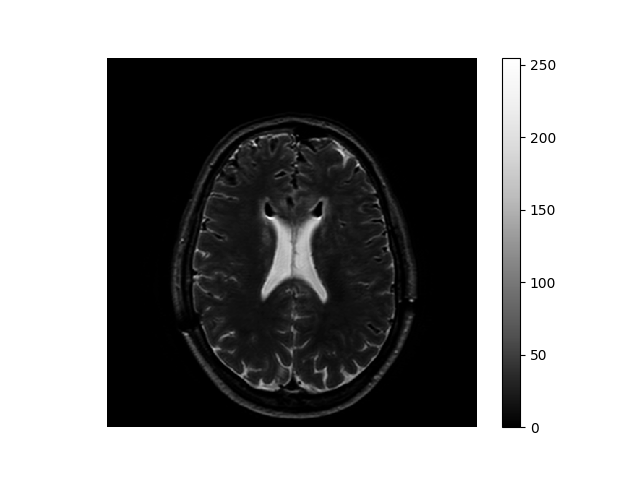
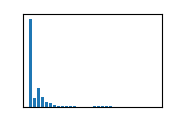

In [77]:
brain_original = cv2.imread("D:/162.tif", cv2.IMREAD_GRAYSCALE)
stackview.insight(brain_original)

## Denoising with Dipy

[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]
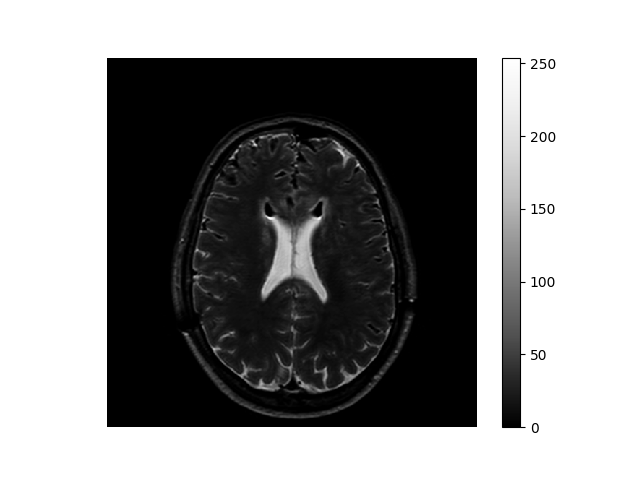
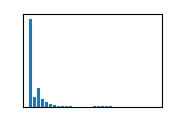

In [120]:
brain_for_dipy = np.stack([brain_original]*5, axis=0)
sigma = estimate_sigma(brain_for_dipy)
denoise_image = nlmeans(
    brain_for_dipy,
    sigma=sigma*0.6,
    patch_radius=1,
    block_radius=1,
    rician=True
)
stackview.insight(denoise_image)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
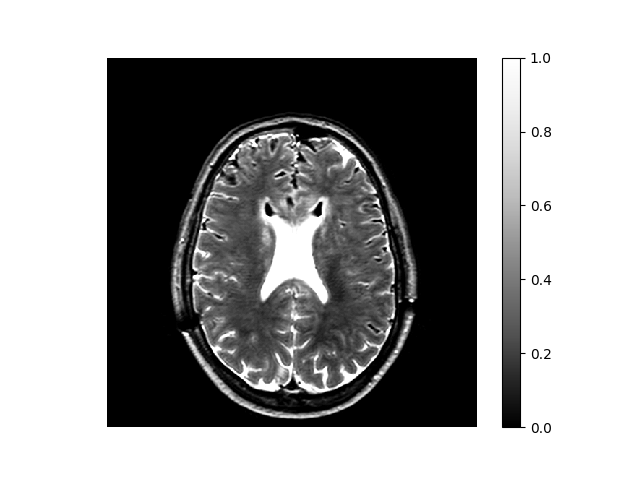
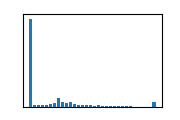

In [104]:
denoise_2 = denoise_image[2].astype(np.float32)
p_low, p_high = np.percentile(denoise_2, (3, 97))
if p_low != p_high:
    stretched = np.clip((denoise_2 - p_low) / (p_high - p_low), 0, 1)
else:
    stretched = np.zeros_like(denoise_2)
stackview.insight(stretched)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
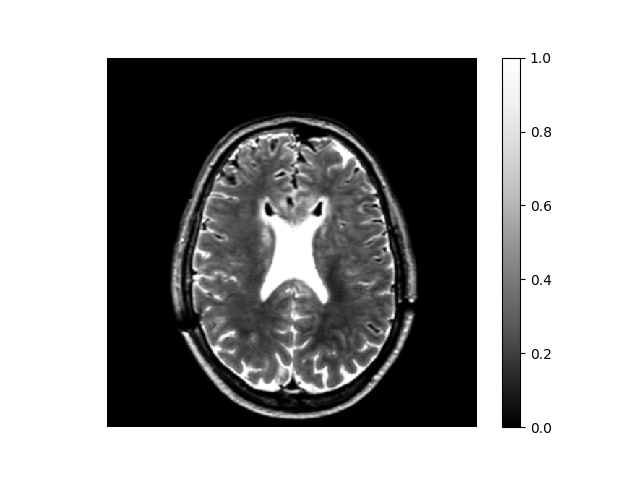
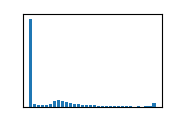

In [71]:
blur = cv2.GaussianBlur(stretched, (5, 5), 0)
stackview.insight(blur)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
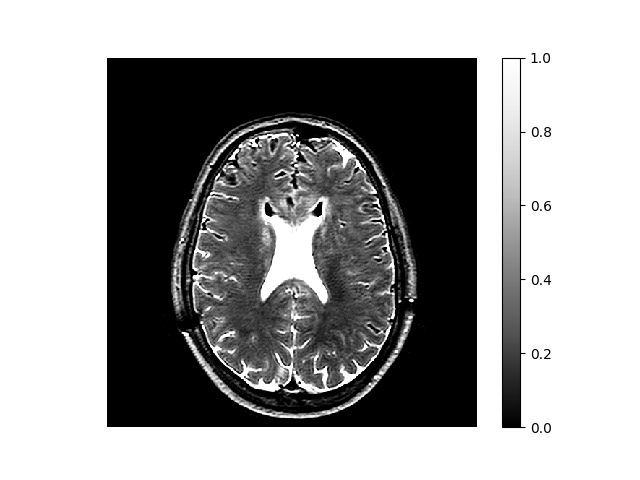
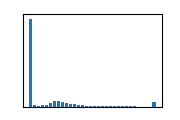

In [106]:
A_factor = 1.8
sharpen_image = cv2.addWeighted(stretched, 1 + A_factor, blur, -A_factor, 0)
sharpen_image = np.clip(sharpen_image, 0, 1) 
stackview.insight(sharpen_image)

[[6 6 6 ... 6 6 6]
 [6 6 6 ... 6 6 6]
 [6 6 6 ... 6 6 6]
 ...
 [6 6 6 ... 6 6 6]
 [6 6 6 ... 6 6 6]
 [6 6 6 ... 6 6 6]]
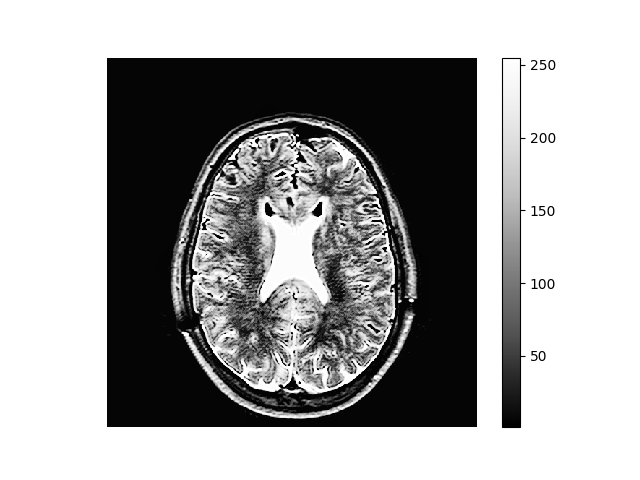
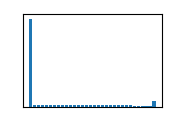

In [110]:
image_uint8 = (sharpen_image * 255).astype(np.uint8)

clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8,8))
enhanced_image = clahe.apply(image_uint8)

stackview.insight(enhanced_image)